# Trading Strategies and the BT Package

> I think that good quant investment managers … can really be thought of as financial economists who have codified their beliefs into a repeatable process. They are distinguished by diversification, sticking to their process with discipline, and the ability to engineer portfolio characteristics. 
— Cliff Asness of AQR (2007)

These notes are based, in part, on Chapter 3.3 of [Efficiently Inefficient by Lasse Pedersen](https://press.princeton.edu/books/hardcover/9780691166193/efficiently-inefficient). It is a nice introduction to more sophisticated investing strategies, like quantitative equity and fixed income arbitrage strategies. I provide many more resources below.  

Broadly speaking, **quantitative investing** tries to turn an investment thesis into a repeatable process. The thesis is often **model driven**, perhaps related to some economic rationale that repeats itself. For example, maybe stocks with certain characteristics generate positive risk-adjusted returns, on average. 

This process often means using **historical** or **simulated** data to test a hypothesis. This process is called **backtesting** -- there's an entire literature that has developed around the best way to backtest strategies. We'll discuss the basic idea here.

Quantitative strategies, regardless of security type, usually have a small amount of alpha per trade. These are not "big swings", like betting against housing in 2007. The model identifies **entry and exit points across a large number of securities**, leading to significant **diversification**, or at least that's the hope.

If you can identify something in the data, then you can trade on it. This might be traditional measures, like value and momentum. Other accounting data gets used to create measures like earnings quality. You can try to quantify management quality. You can look at flow in and out of a security, trying to identify who is trading. You can use the limit order book itself. You can use natural language processing (NLP) and text data. I give you some examples below. 

Some quantitative trading strategies are very short-term and high turnover, like those that use the limit order book. Others hold securities for months, if not years, like value. 

Many strategies have a **long and short component**. You buy a basket of securities (e.g. stocks, currencies, crypto, etc.) that have the positive set of characteristics that you're looking at and short a basket of securities that have the negative set. Going long and short can help mitigate risk, but there's a lot that goes into it. Exactly how should you weight your positions? Should you try to be market beta neutral in your overall portfolio? What about sector bets? Going long deep value will have you buying lots and lots of bank stocks. How do you feel about that kind of concentration?

The end-goal: create a portfolio with the risks and characteristics that you want, while eliminating the ones that you don't want. This, somewhat optimistically, is sometimes called a **market neutral portfolio**. Like an equity market neutral hedge fund -- they try to make money no matter what the overall market is doing. Quants try to estimate the relation between the signal value and the expected return and construct the portfolio and the rebalancing strategy that maximizes performance after transaction costs.

For differences between risk factors and anomalies, see the chapter on factor models. Both could be present in a quantitative trading portfolio. Understand your market to know what the risks and anomalies are. It is often hard (impossible?) to know which is which.

## Steps in Strategy Development

Here are the typical steps for developing a quantitative trading strategy.

1. **Identify a hypothesis or market inefficiency**: Develop a hypothesis about a market inefficiency that your strategy will exploit. This could be based on trends, patterns, or relationships between financial instruments or market data. **This is the hard part!** If you want to do this for real, I strongly suggest trying to find a niche market, something without a lot of volume, something too small for larger investors to trade in. You are very unlikely to have any kind of advantage trading U.S. equities. You could try to re-create one of the well-known strategies used by some [factor-based ETFs](https://www.blackrock.com/us/financial-professionals/products/factor-etfs#Minimum-Volatility), but you will be at a trading-cost disadvantage.

2. **Gather and preprocess data**: Collect relevant historical data for your hypothesis, such as price, volume, and other financial indicators. Preprocess the data to ensure it is clean and consistent, accounting for issues like missing values, outliers, and data errors. This crucial step is why we spent so much time mucking around in `pandas` looking for **NA** values and [bad dates](https://www.youtube.com/watch?v=0qIMTA4_YdU). What are your data sources? Do you have a data advantage? Everyone has moved to [alternative data](https://data.nasdaq.com/alternative-data) the past decade, with varying degrees of success. Data costs get very expensive, very quickly. Even just having a Bloomberg terminal is going to be too much for an individual investor. **Play in markets where you don't need one.**
   
3. **Feature engineering and selection**: Create features or variables (features are the machine learning way of saying "variable") that capture relevant information for your strategy. This could include technical indicators, fundamental analysis, or sentiment analysis. Perform feature selection to identify the most important variables for your strategy. Steps 2 and 3 are the **data engineering** steps. These jobs often [pay more](https://www.efinancialcareers.com/news/2023/03/quant-developers-vs-quant-researchers) than the hypothesis development roles!
   
4. **Develop a trading model**: Use your selected features to build a quantitative model. This could involve statistical methods, machine learning techniques, or optimization algorithms. Split your data into training and testing sets to avoid overfitting and to assess your model's performance. Most of these models are "off the shelf" these days. In other words, there's little alpha in fancy math. **Linear regression** and logit are commonly used. Even the fanciest machine learning techniques available have already been coded up in Python (or another language) by our friends in the computer science world. Still, different techniques come in and out of fashion, so the quant researcher wants to stay up on what's going on. Then, we just go back to calculating conditional means in our OLS model. 

5. **Backtesting**: Test your strategy on historical data to evaluate its performance. This step is crucial to determine if the strategy would have been profitable in the past. Assess various performance metrics, such as the Sharpe ratio, maximum drawdown, and annualized returns. **These notes focus on this step**. We are going to use the [bt package](https://pypi.org/project/bt/). There's obviously much more that goes into it. 

6. **Risk management**: Incorporate risk management rules to protect your capital and minimize losses. This could include position sizing, stop-loss orders, and diversification techniques.

7. **Optimization and sensitivity analysis**: Optimize your strategy's parameters and perform sensitivity analysis to assess its robustness. Ensure that your strategy is not overly sensitive to small changes in input parameters. We've seen these last two steps in previous chapters. Your quant model might use an optimizer to form portfolios, while calculating various risk measures in order to understand sources of returns and the possible downside.

8. **Walk-forward analysis or out-of-sample testing**: Validate your strategy on new, unseen data to assess its real-world performance. This step helps to mitigate the risk of overfitting and provides a more realistic assessment of the strategy's potential success. You are going to find strategies that look great in a backtest. That's pretty easy, especially if you overfit your model. You will quickly find out that your strategy doesn't work out-of-sample (i.e. in new data).

9.  **Implementation**: Develop a trading infrastructure to execute your strategy. This can involve creating a trading algorithm, selecting a broker, and ensuring low-latency execution. Monitor the strategy's performance and make adjustments as necessary. This step is especially important if your strategy trades a lot -- trading costs will destroy any alpha that you have. If you trade less frequently (e.g. every quarter), then it's not as big a deal. 

10. **Review and refine**: Continuously monitor and evaluate your strategy's performance. Update your models and data as needed, and be prepared to refine your strategy if market conditions change or if its performance begins to deteriorate. But, also know when to leave things alone. All strategies underperform at some point. You have to know when things are going to revert back to normal vs. when your strategy is cooked. 


## Ideas and Resources

These notes don't even scratch the surface on what it takes to really run a trading strategy. However, I want to point you towards resources and ideas that may help. In the end, though, most of the learning is done by actually doing this stuff, either tinkering on your own or on a trading desk. 

You can find academic and practitioner papers on [SSRN](https://www.ssrn.com/index.cfm/en/). 

Short guide on [backtesting trading strategies](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2345489) by [Cam Harvey et al. at Fuqua](https://www.fuqua.duke.edu/faculty/campbell-harvey). 

Short guide on [evaluating](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2474755) trading strategies, again by [Cam Harvey et al.](https://www.fuqua.duke.edu/faculty/campbell-harvey). 

Discussion of [151 different trading strategies](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3247865). These are all very well-known, but give you a sense of what might have worked in the past. Maybe see if they work in a new market? 

Description of [time series momentum strategies](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1968996) and how to implement them. There are a million flavors of these strategies. Note that momentum and trend following aren't the same thing. 

Quantitative ["deep value" strategy](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3076181) from the hedge fund [AQR](https://www.aqr.com). They had a rough few years when growth was dramatically outperforming value. 

More evidence for [trend following](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2993026). Why the focus on that here? It's one of the easier strategies to mess around with and is the typical example used for quant strategies. 

Even more [trend is your friend](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2603731), also from AQR and published in the [Financial Analysts Journal](https://www.cfainstitute.org/en/research/financial-analysts-journal#sort=%40officialz32xdate%20descending). 

Fun paper that uses machine learning and [actual images of stock price charts](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3756587) to create trend-following strategies. 

Predicting returns using [text data](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3389884). Everyone is trying this the past five to ten years. 

Example of [momentum combined with other signals](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1127213) from the commodities market. 

[Pairs trading with ETFs](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=1958546). A different type of example! 

Once [everyone knows about an anomaly, is it still profitable to trade on it](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2816490)? 

Finally, here are some **books that might interest you**.

Free book on [developing quantitative equity strategies]( https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2543802). However, I get nervous whenever I see "econophysics" or "multifractal". There is a long history of physics people doing strange things in finance and economics, thinking that they have discovered some fundamental insight that everyone else has missed for hundreds of years.

The [2nd edition of Quantitative Portfolio Management](https://www.amazon.com/Quantitative-Equity-Portfolio-Management-Second-ebook/dp/B09KF52TKD) was published in the Fall of 2022. The authors also cover how to use fundamental features based on financial statement items to select equity securities. 

Another updated [quantitative trading](https://www.amazon.com/Quantitative-Trading-Build-Algorithmic-Business-dp-1119800064/dp/1119800064/) text. 

Another physicist looking at [pairs trading and statistical arbitrage](https://www.amazon.com/Quantitative-Portfolio-Management-Statistical-Arbitrage-ebook/dp/B09FZVTM64/). 

Discussion of some [simple quantitative strategies](https://www.amazon.com/DIY-Financial-Advisor-Solution-Protect/dp/111907150X/) that you can automate.

## Using the BT Package

I am going to walk through the basic example using the [BT package](https://pypi.org/project/bt/). You should check out their support page for more. From their page:

> bt is a flexible backtesting framework for Python used to test quantitative trading strategies. Backtesting is the process of testing a strategy over a given data set. This framework allows you to easily create strategies that mix and match different Algos. It aims to foster the creation of easily testable, re-usable and flexible blocks of strategy logic to facilitate the rapid development of complex trading strategies. The goal: to save quants from re-inventing the wheel and let them focus on the important part of the job - strategy development

You will need to install the BT package using `pip`. 

```
pip install bt
```

The example comes from [the author's github page](http://pmorissette.github.io/bt/). 

Note that the `bt` package uses the `ffn` package, which contains a lot of nice finance-helper functions written by the same author. For example, we're going to use it to get data below. You can also [read more about it](http://pmorissette.github.io/ffn/).

When we bring in `bt`, we are also bringing in `ffn`. 

There are many, many options that you can include as you develop your strategy. If you want details, check out [this page](https://pmorissette.github.io/bt/bt.html). 

In [1]:
# The usual type of set-up.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bt as bt
import ffn as ffn

# Include this to have plots show up in your Jupyter notebook.
%matplotlib inline 

# As of Dec 2022, looks like yfinance broke the ffn/bt data import. Add this to get it to work. See https://github.com/pmorissette/ffn/issues/185
import yfinance as yf

### Step 1 - Get your data

The first step is to get the appropriate data. Now, we are going to bring in some basic stock and bond data. This is silly, but instructive. You'll likely spend a lot of time here dealing with APIs to bring in more unusual data. We're going to look at a strategy that **just uses prices**. What about fundamental data, like earnings quality? How about text? This is why the data engineering steps are so important. 

Note that `ffn.get` works as well to get data from Yahoo! Finance.

In [2]:
tickers = ['SPY', 'AGG']
data = yf.download(tickers, start='2010-01-01')
data = data['Close'].copy()
data = data.dropna()
data.head()

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

Ticker,AGG,SPY
Date,,
2010-01-04,66.067131,85.027946
2010-01-05,66.367722,85.253052
2010-01-06,66.329376,85.313034
2010-01-07,66.252640,85.673210
2010-01-08,66.291069,85.958282


### Step 2 - Define your strategy

The `bt` package has you create a **strategy object**. This object has a name and contains various characteristics for your strategy, such as how often to run your strategy, the securities to select from your data, your weighting scheme, and your rebalancing frequency.

The code example below runs monthly, selects all of the securities from the data given to it, weights the securities equally, and then rebalances to get back to those target weights.

Our strategy is going to be called **ew**, since this strategy equally weights all of the securities each month. Not much of an algo there! It then gets saved as a strategy object also called **ew**. 

Note that this **is not** a "buy-and-hold" strategy, since we are rebalancing back to equally weighted each month. There's a `bt.algos.RunOnce` for that.

In [3]:
ew = bt.Strategy('ew', [bt.algos.RunMonthly(),
                       bt.algos.SelectAll(),
                       bt.algos.WeighEqually(),
                       bt.algos.Rebalance()])

print(type(ew))

<class 'bt.core.Strategy'>


Now, note that there's no real trading strategy yet. **We haven't included any trading logic.** What is an algorithm, or **algo**, in quant trading? Basically, it is a series of rules to get you a boolean (1/0) output. Do you include this security in your portfolio? Do you exclude it? Or, you can add a -1 outcome and ask if you short it. 

What do I mean by **rules**? This is the trading strategy! Does the security have positive trend? Momentum? Meet some quality measure? Is it being impacted by retail trading flow and will mean revert in the next hour? Are you predicting that the firm will be a target of a shareholder activist? These are all rules that might lead you to go long or short the security.

Let's create some actual, simple trading logic. I'll follow the [moving average example](http://pmorissette.github.io/bt/examples.html) from the `bt` author. We can then compare strategies.

I'll use a 50-day moving average, like the author. We'll then compare our two securities to their moving average. If the price is above the moving average, let's call that positive trend and buy. If not, we'll exclude the security from the portfolio. Simple **boolean logic**. 

Again, this is a very simple strategy on a stock and a bond index! We'll make things more interesting later in this chapter.

In [4]:
sma = data.rolling(50).mean()

What did I just create? Let's look.

In [5]:
sma

Ticker,AGG,SPY
Date,,
2010-01-04,NaN,NaN
2010-01-05,NaN,NaN
2010-01-06,NaN,NaN
2010-01-07,NaN,NaN
2010-01-08,NaN,NaN
...,...,...
2026-03-05,100.007900,688.298997
2026-03-06,100.020520,688.049996
2026-03-09,100.039540,687.856196


See how the first rows are missing? This is a 50-day moving average, so you don't get an average until 50 days have passed. 

The `bt` package has merge and plot methods. The package is pulling them from `pandas` and `matplotlib`. This just makes things easier for us.

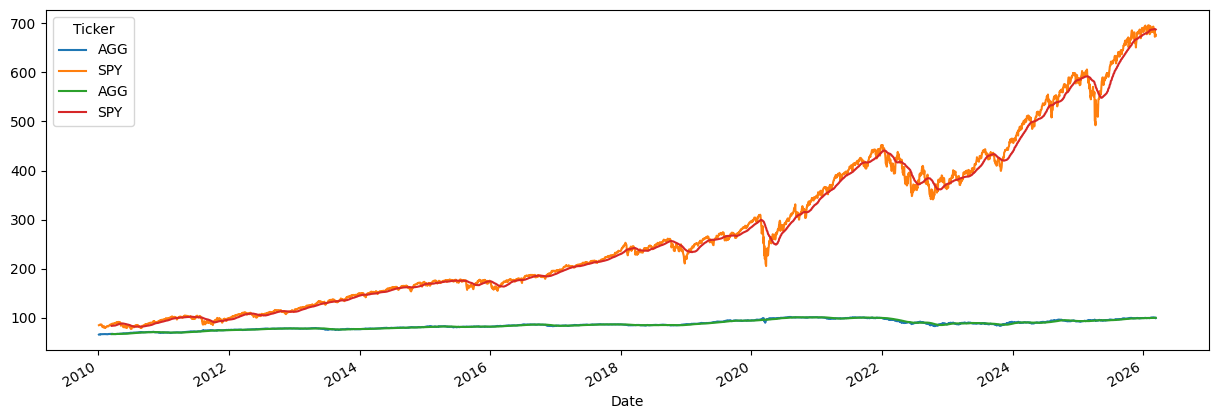

In [6]:
plot = bt.merge(data, sma).plot(figsize=(15, 5))

Now, let's use that **Boolean logic** to create our **signal**. When do we buy? When the price is above the 50-day moving average. Just compare the two DataFrames and get a new one full of *True* and *False* values! We'll call that DataFrame **signal**. 

In [7]:
signal = data > sma
print(type(signal))

signal

<class 'pandas.DataFrame'>


Ticker,AGG,SPY
Date,,
2010-01-04,False,False
2010-01-05,False,False
2010-01-06,False,False
2010-01-07,False,False
2010-01-08,False,False
...,...,...
2026-03-05,True,False
2026-03-06,True,False
2026-03-09,True,False


We can now create a **new strategy** with that logic. The new strategy is called **above50sma** and is saved in the **sma50** object. Notice the new first line that has the `.SelectWhere` method. This is going to select securities where `signal == True`.

In [8]:
sma50 = bt.Strategy('above50sma', [bt.algos.SelectWhere(signal),
                                   bt.algos.WeighEqually(),
                                   bt.algos.Rebalance()])

Take a look at this discussion on [strategy trees](http://pmorissette.github.io/bt/tree.html) for more on how to use `bt` to combine different algorithms. 

A real strategy might incorporate **hundreds of signals from all types of data sources**. 

### Step 3 - Backtest your strategy

Once you have your strategy object, you can backtest it on your data. You feed the function `bt.Backtest` your strategy and your data. This creates a **test** object. Then, you use `bt.run` on that object to get your **results**.

One nice feature of `bt`: you can run **multiple backtests at once** and compare them side by side. Let's do that with our equal-weight and moving average strategies.

In [9]:
test_ew = bt.Backtest(ew, data)
test_sma50 = bt.Backtest(sma50, data)

# Run both backtests together
res = bt.run(test_ew, test_sma50)

print(type(res))

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:01<00:01,  1.51s/it]

100%|██████████| 2/2 [00:03<00:00,  2.02s/it]

100%|██████████| 2/2 [00:03<00:00,  1.94s/it]

<class 'bt.backtest.Result'>


Note the arguments for the backtest function. You give it the strategy and your **data**. Remember, your data are prices for the securities. The backtest uses these prices to generate returns. We pass both backtests into `bt.run` together so that we can compare them easily.

With the results object, we can plot the value of both strategies (starting at 100) and look at some descriptive statistics side by side.

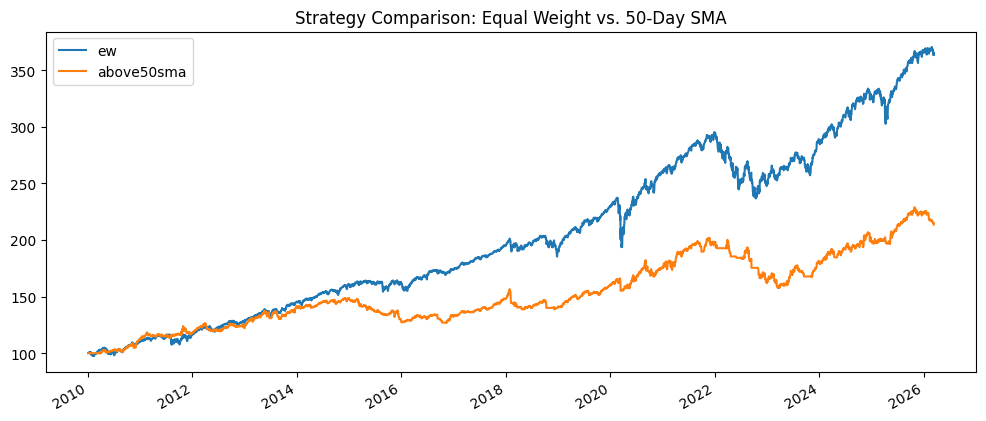

In [10]:
res.plot(figsize=(12, 5), title='Strategy Comparison: Equal Weight vs. 50-Day SMA');

In [11]:
res.display()

Stat                 ew          above50sma
-------------------  ----------  ------------
Start                2010-01-03  2010-01-03
End                  2026-03-11  2026-03-11
Risk-free rate       0.00%       0.00%

Total Return         263.48%     113.66%
Daily Sharpe         0.95        0.64
Daily Sortino        1.48        0.95
CAGR                 8.30%       4.80%
Max Drawdown         -19.87%     -21.94%
Calmar Ratio         0.42        0.22

MTD                  -1.58%      -1.45%
3m                   -0.86%      -5.18%
6m                   1.89%       -4.01%
YTD                  -0.53%      -4.29%
1Y                   13.55%      6.95%
3Y (ann.)            12.78%      10.30%
5Y (ann.)            6.58%       3.62%
10Y (ann.)           8.36%       5.09%
Since Incep. (ann.)  8.30%       4.80%

Daily Sharpe         0.95        0.64
Daily Sortino        1.48        0.95
Daily Mean (ann.)    8.38%       5.00%
Daily Vol (ann.)     8.80%       7.78%
Daily Skew           -0.54       -0

Let's also look at **drawdowns**. A drawdown measures the decline from a portfolio's peak value. This is one of the most important risk measures -- investors feel losses more than gains. The **maximum drawdown** tells you the worst peak-to-trough decline over the backtest period. We can calculate drawdowns from the strategy's price series.

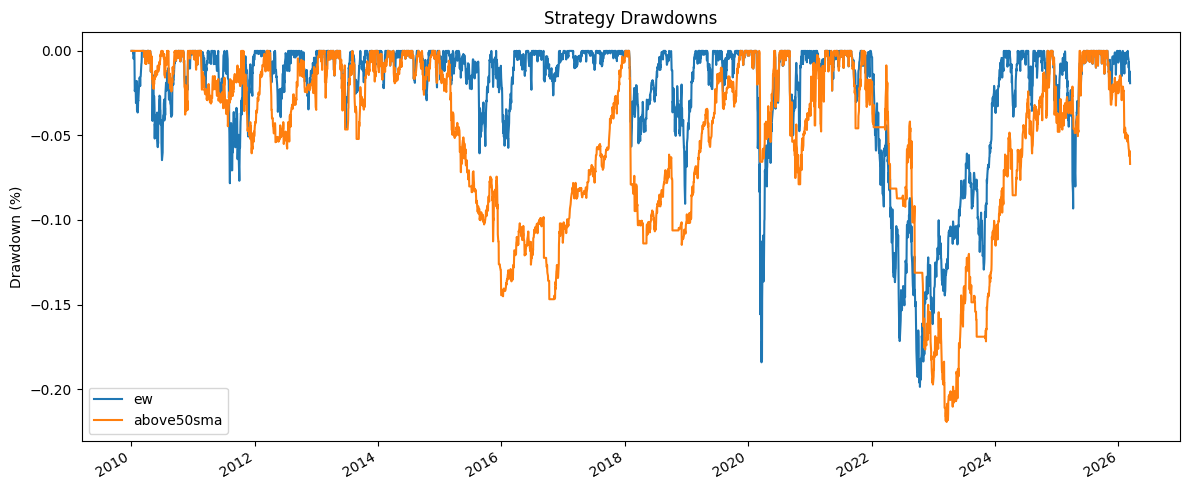

In [12]:
# Calculate and plot drawdowns manually
# Drawdown = (current price - running max) / running max
drawdowns = res.prices / res.prices.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 5))
drawdowns.plot(ax=ax)
ax.set_title('Strategy Drawdowns')
ax.set_ylabel('Drawdown (%)')
ax.legend()
plt.tight_layout()
plt.show()

We can also look at the **security weights over time**. This shows you how the portfolio allocation changes at each rebalance. For the equal-weight strategy, you'll see it stays roughly 50/50. For the SMA strategy, securities drop out when they fall below their moving average.

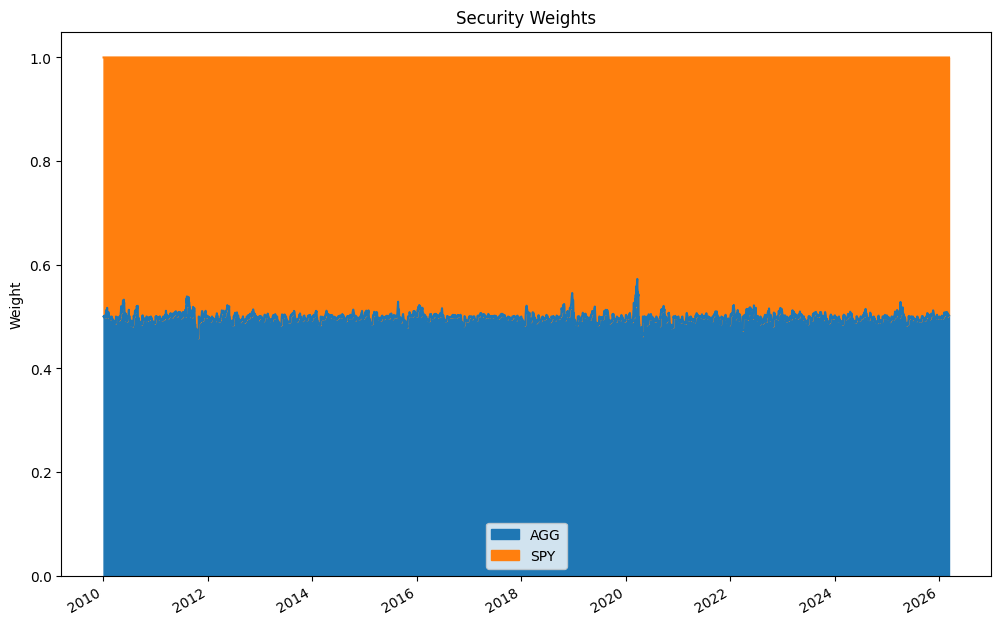

In [13]:
weights = res.get_security_weights()
weights = weights.iloc[1:]

fig, ax = plt.subplots(figsize=(12, 8))
weights.plot.area(ax=ax)
ax.set_title('Security Weights')
ax.set_ylabel('Weight')
ax.legend(loc='best');

You'd have been much better off equally weighting the two indices and rebalancing each month! The SMA strategy spent a lot of time out of the market, missing rallies, and that hurt performance.

But this was a very simple example with just two securities. Let's make things more realistic and explore more of what the `bt` package can do.

## Backtesting Pitfalls

Before we build more strategies, let's talk about what can go wrong. Backtesting is seductive -- you can always find a strategy that looks great on historical data. The hard part is finding one that works **going forward**. Here are the most common pitfalls.

### Look-Ahead Bias

**Look-ahead bias** occurs when your backtest uses information that would not have been available at the time of the trade. For example, if you use tomorrow's closing price to make today's trading decision, your backtest will look fantastic, but you'd never be able to replicate it in real time. This also happens with fundamental data -- quarterly earnings aren't available on the last day of the quarter. They're reported weeks later.

The `bt` package helps with this by design. When you create a signal using historical prices (like our moving average), you're only using past data. But be careful when constructing your own signals outside of `bt` -- it's easy to accidentally peek into the future.

### Survivorship Bias

**Survivorship bias** happens when your data set only includes securities that still exist today. If a stock went bankrupt in 2015, it won't show up in today's Yahoo Finance data. Your backtest never sees the losers, making performance look better than it actually would have been. This is a huge problem with stock data.

For our examples using ETFs like SPY, this isn't as big a deal -- these are diversified indices. But if you were backtesting a strategy that picks individual stocks, you'd need a database that includes **delisted securities**. That kind of data costs money.

### Overfitting

**Overfitting** is the cardinal sin of backtesting. If you try enough parameter combinations, you'll find something that works beautifully on your historical data but fails on new data. Did you try a 50-day moving average and it didn't work, so you tried 47 days and that looked better? Congratulations, you may have just overfit your model.

A good rule of thumb: the simpler the strategy, the less likely it is to be overfit. Strategies with fewer parameters are more robust. If your strategy requires 15 precisely tuned parameters, you're probably fitting noise, not signal.

### Transaction Costs

Every trade costs money. There's the **bid-ask spread** (you buy at the ask and sell at the bid), **commissions** (smaller these days, but not zero for all brokers), and **market impact** (your trade moves the price, especially in less liquid markets). A strategy that rebalances daily with 50 securities will generate a lot of trades. Even small transaction costs compound quickly and can turn a profitable backtest into a losing real-world strategy.

We'll see how to add transaction costs to `bt` backtests below.

### Data Snooping

Related to overfitting, **data snooping** or **p-hacking** happens when you test many strategies on the same data set. If you test 100 strategies, about 5 will "work" at the 5% significance level purely by chance. The academic literature has grappled with this problem extensively -- see the Cam Harvey papers referenced above.

### Regime Changes

Markets change over time. Interest rates, volatility, correlations, regulations, and market microstructure all evolve. A strategy calibrated to the low-volatility, low-rate environment of 2012-2019 may not work in a rising rate environment. This is why **out-of-sample testing** is so important -- and why you should be skeptical of any backtest that only covers a single market regime.

## A More Realistic Example: Trend Following with Sector ETFs

Let's build something more interesting. We'll use a set of **sector ETFs** and apply a trend-following strategy. This is closer to what a real quantitative strategy might look like, at least in spirit. The universe is larger, we'll compare multiple signal definitions, and we'll consider transaction costs.

Our investment universe will be the major U.S. sector ETFs. These are liquid, have long histories, and each represents a different part of the economy. A trend-following strategy will try to identify which sectors have positive momentum and overweight or buy those, while avoiding sectors in a downtrend.

In [14]:
# Sector ETFs - these cover the major S&P 500 sectors
sector_tickers = ['XLK',  # Technology
                  'XLF',  # Financials
                  'XLV',  # Health Care
                  'XLE',  # Energy
                  'XLY',  # Consumer Discretionary
                  'XLP',  # Consumer Staples
                  'XLI',  # Industrials
                  'XLU',  # Utilities
                  'XLB',  # Materials
                  'XLRE'] # Real Estate (started in 2015)

sector_data = yf.download(sector_tickers, start='2015-01-01')
sector_data = sector_data['Close'].copy()

# Drop any rows with NaN values (incomplete trading days)
sector_data = sector_data.dropna()

print(f"Data shape: {sector_data.shape}")
print(f"Date range: {sector_data.index[0].strftime('%Y-%m-%d')} to {sector_data.index[-1].strftime('%Y-%m-%d')}")
sector_data.head()

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**********            20%                       ]  2 of 10 completed

[**********************50%                       ]  5 of 10 completed

[**********************60%****                   ]  6 of 10 completed

...

[**********************80%*************          ]  8 of 10 completed

[**********************90%******************     ]  9 of 10 completed

[*********************100%***********************]  10 of 10 completed

Data shape: (2620, 10)
Date range: 2015-10-08 to 2026-03-11


Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,
2015-10-08,17.947424,22.906586,15.673992,44.282913,18.358347,37.508648,21.185568,15.831946,57.437988,34.710804
2015-10-09,17.939306,22.758036,15.573469,44.432739,18.438362,37.592262,21.150505,15.756377,57.699345,34.751041
2015-10-12,17.784895,22.464230,15.586871,44.441074,18.460594,37.691071,21.283754,15.896707,57.851086,34.916481
2015-10-13,17.715818,22.229853,15.466252,43.966614,18.420582,37.463047,21.150505,15.860734,57.126034,34.728691
2015-10-14,17.858032,22.421316,15.338930,43.492142,18.385023,37.029827,21.150505,15.857124,57.016445,34.375446


### Strategy 1: Buy-and-Hold Benchmark

Every strategy comparison needs a **benchmark**. The simplest benchmark is buy-and-hold: buy equal weights of all sectors on day one and never rebalance. This is your baseline. If your fancy trading strategy can't beat buy-and-hold, why bother?

In `bt`, we use `bt.algos.RunOnce()` to set up a buy-and-hold strategy. The algo runs only once at the start, selects all securities, weights them equally, and then sits there.

In [15]:
# Buy-and-hold: invest once, never rebalance
benchmark = bt.Strategy('buy_and_hold', [bt.algos.RunOnce(),
                                         bt.algos.SelectAll(),
                                         bt.algos.WeighEqually(),
                                         bt.algos.Rebalance()])

### Strategy 2: Monthly Rebalanced Equal Weight

Like our earlier example, but across all sectors. Rebalance to equal weight each month. This is an active strategy in the sense that it sells winners and buys losers each month to maintain equal weights -- a mild **contrarian** tilt.

In [16]:
# Monthly rebalanced equal weight
ew_monthly = bt.Strategy('ew_monthly', [bt.algos.RunMonthly(),
                                        bt.algos.SelectAll(),
                                        bt.algos.WeighEqually(),
                                        bt.algos.Rebalance()])

### Strategy 3: SMA Crossover Trend Following

Now for our actual trading strategy. This is a classic **moving average crossover**: buy a sector when its **short-term moving average** crosses above its **long-term moving average**. This is a stronger trend signal than just comparing the price to a single moving average, because the short-term average smooths out daily noise.

We'll use a **50-day** and **200-day** moving average. When the 50-day crosses above the 200-day, the sector is in an uptrend (sometimes called a "golden cross" in technical analysis). When it crosses below, the sector is in a downtrend ("death cross"). This is one of the oldest technical indicators out there.

Sectors that pass the filter get equally weighted. Sectors that don't pass get excluded -- the strategy holds cash for that portion instead.

In [17]:
# Calculate short and long moving averages
sma_short = sector_data.rolling(50).mean()
sma_long = sector_data.rolling(200).mean()

# Signal: short MA above long MA = uptrend
crossover_signal = sma_short > sma_long

# Let's look at the signal for one ETF to see what's happening
print("XLK trend signal (last 10 rows):")
print(crossover_signal['XLK'].tail(10))

XLK trend signal (last 10 rows):
Date
2026-02-26    True
2026-02-27    True
2026-03-02    True
2026-03-03    True
2026-03-04    True
2026-03-05    True
2026-03-06    True
2026-03-09    True
2026-03-10    True
2026-03-11    True
Name: XLK, dtype: bool


Let's visualize the moving averages and signal for one sector to see what's going on. When the blue 50-day line is above the orange 200-day line, that's our buy signal.

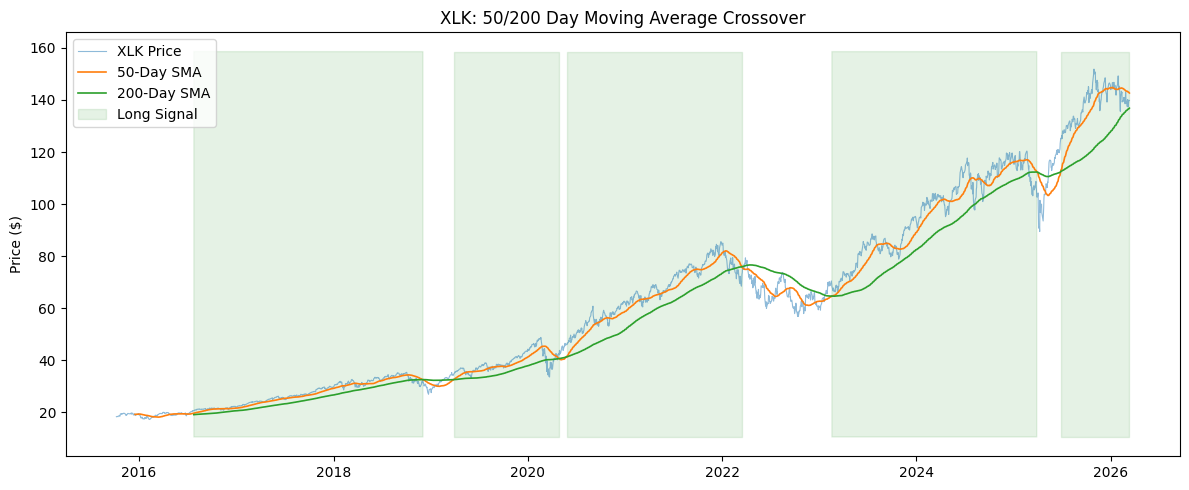

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sector_data['XLK'], label='XLK Price', alpha=0.5, linewidth=0.8)
ax.plot(sma_short['XLK'], label='50-Day SMA', linewidth=1.2)
ax.plot(sma_long['XLK'], label='200-Day SMA', linewidth=1.2)

# Shade the regions where we'd be invested
ax.fill_between(crossover_signal.index, 
                ax.get_ylim()[0], ax.get_ylim()[1],
                where=crossover_signal['XLK'], 
                alpha=0.1, color='green', label='Long Signal')

ax.set_title('XLK: 50/200 Day Moving Average Crossover')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

Now let's build the `bt` strategy. We'll rebalance monthly -- we don't need to trade every day just because we have a daily signal. Monthly rebalancing is more realistic and keeps transaction costs lower. The `RunMonthly` algo checks the signal at the end of each month.

In [19]:
# SMA crossover: only buy sectors in an uptrend (50-day > 200-day)
sma_crossover = bt.Strategy('sma_crossover', [bt.algos.RunMonthly(),
                                               bt.algos.SelectWhere(crossover_signal),
                                               bt.algos.WeighEqually(),
                                               bt.algos.Rebalance()])

### Strategy 4: Momentum (Return-Based Signal)

Let's try a different kind of trend signal. Instead of moving averages, we'll use **past returns** directly. This is a **momentum** strategy: buy the sectors that have done well over the past few months. We'll rank sectors by their trailing 6-month return and only hold the **top half**.

Why the top half? In a pure long-only context, we want to concentrate on winners. In a long-short strategy, you'd go long the top and short the bottom. We'll keep it long-only here.

The `bt` package has `SelectMomentum` for this -- it ranks securities by their trailing return over a `lookback` period and selects the top `n`. We use `SelectAll` first to give it the full universe to rank from.

In [20]:
# How many sectors do we want to hold? Top half.
n_sectors = len(sector_data.columns)
n_hold = n_sectors // 2

print(f"Universe: {n_sectors} sectors, holding top {n_hold}")

# Momentum strategy: buy the top N sectors by trailing 6-month return
# SelectAll first gives SelectMomentum the full universe to rank
momentum = bt.Strategy('momentum', [bt.algos.RunMonthly(),
                                     bt.algos.SelectAll(),
                                     bt.algos.SelectMomentum(n=n_hold, 
                                                             lookback=pd.DateOffset(months=6)),
                                     bt.algos.WeighEqually(),
                                     bt.algos.Rebalance()])

Universe: 10 sectors, holding top 5


### Running All Strategies

Now let's run all four strategies and compare them. This is where `bt` really shines -- you can run multiple backtests in a single call and get side-by-side comparisons.

In [21]:
# Create backtests for all strategies
test_bh = bt.Backtest(benchmark, sector_data)
test_ew_m = bt.Backtest(ew_monthly, sector_data)
test_cross = bt.Backtest(sma_crossover, sector_data)
test_mom = bt.Backtest(momentum, sector_data)

# Run them all at once
sector_res = bt.run(test_bh, test_ew_m, test_cross, test_mom)

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:01<00:03,  1.00s/it]

 50%|█████     | 2/4 [00:02<00:02,  1.36s/it]

 75%|███████▌  | 3/4 [00:03<00:01,  1.37s/it]

100%|██████████| 4/4 [00:05<00:00,  1.33s/it]

100%|██████████| 4/4 [00:05<00:00,  1.31s/it]

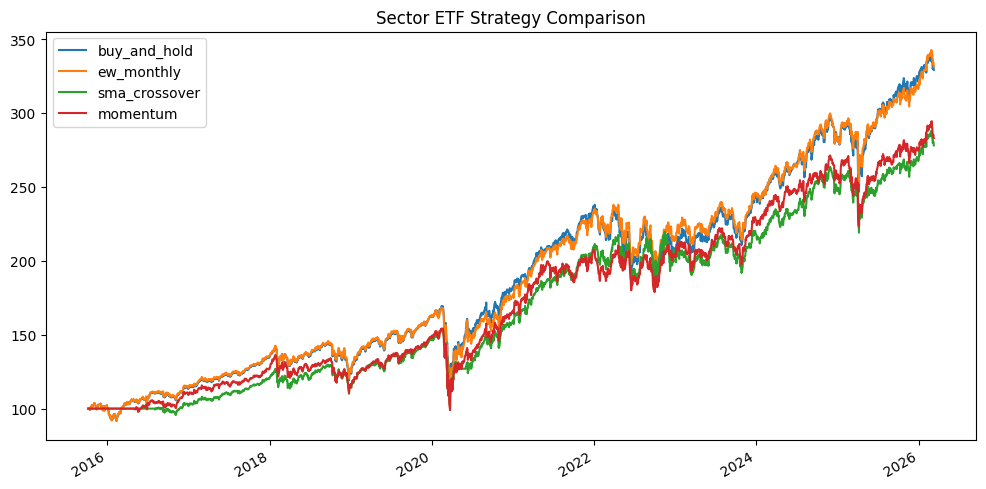

In [22]:
sector_res.plot(figsize=(12, 6), title='Sector ETF Strategy Comparison');

In [23]:
sector_res.display()

Stat                 buy_and_hold    ew_monthly    sma_crossover    momentum
-------------------  --------------  ------------  ---------------  ----------
Start                2015-10-07      2015-10-07    2015-10-07       2015-10-07
End                  2026-03-11      2026-03-11    2026-03-11       2026-03-11
Risk-free rate       0.00%           0.00%         0.00%            0.00%

Total Return         229.29%         231.25%       178.22%          183.06%
Daily Sharpe         0.76            0.77          0.69             0.68
Daily Sortino        1.17            1.18          1.04             1.05
CAGR                 12.11%          12.17%        10.31%           10.49%
Max Drawdown         -35.71%         -36.88%       -34.67%          -35.83%
Calmar Ratio         0.34            0.33          0.30             0.29

MTD                  -2.85%          -3.34%        -3.37%           -3.77%
3m                   1.70%           4.23%         3.54%            2.35%
6m             

Let's look at the drawdowns. This tells us about the **worst periods** for each strategy. A key question: does the trend-following strategy protect you during drawdowns? That's one of the main selling points of trend following -- it gets you out before the big losses.

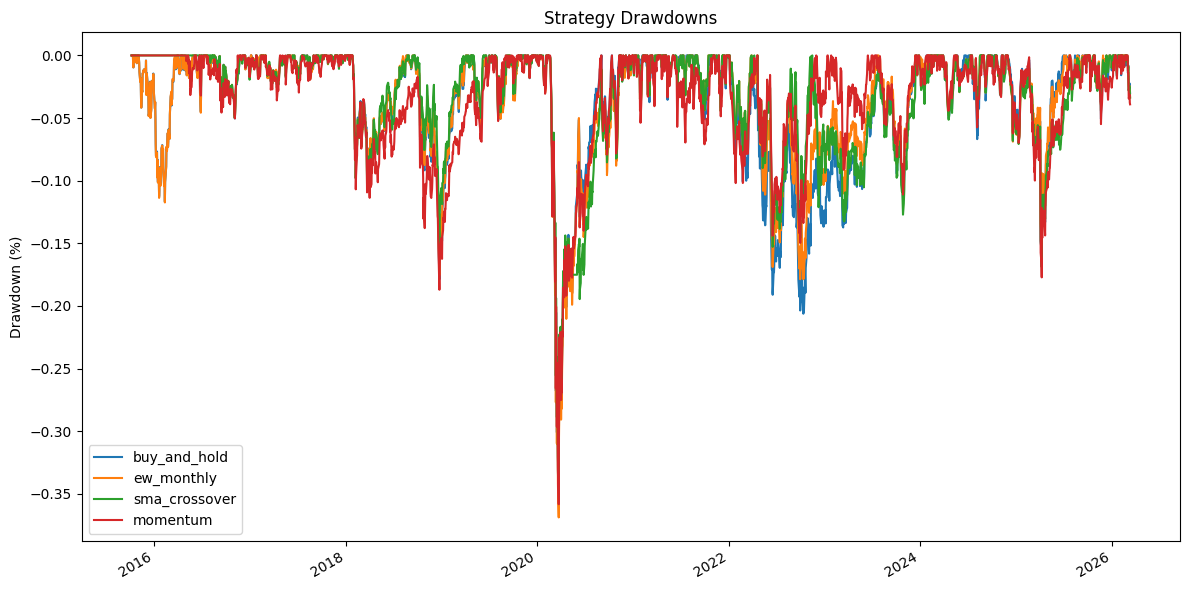

In [24]:
# Calculate drawdowns for sector strategies
sector_dd = sector_res.prices / sector_res.prices.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 6))
sector_dd.plot(ax=ax)
ax.set_title('Strategy Drawdowns')
ax.set_ylabel('Drawdown (%)')
ax.legend()
plt.tight_layout()
plt.show()

Now let's look at how the portfolio weights change over time for the SMA crossover strategy. This shows which sectors the strategy is invested in at each point. When a sector drops below the moving average crossover, it gets excluded and the remaining sectors share the portfolio equally.

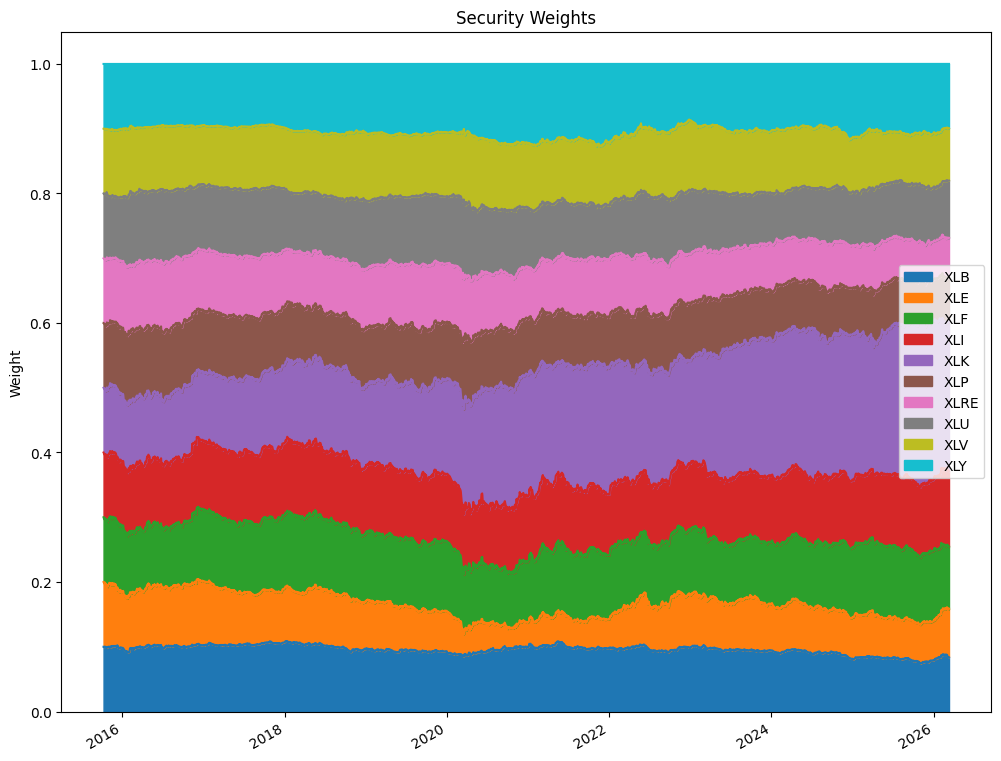

In [25]:
weights = sector_res.get_security_weights()
weights = weights.iloc[1:]

fig, ax = plt.subplots(figsize=(12, 10))
weights.plot.area(ax=ax)
ax.set_title('Security Weights')
ax.set_ylabel('Weight')
ax.legend(loc='best');

## Adding Transaction Costs

So far, our backtests assume **zero transaction costs**. That's not realistic. Every time you buy or sell, you incur costs. For liquid ETFs, these costs are small but not zero. A reasonable estimate might be **10 basis points (0.10%)** per trade for ETFs, accounting for bid-ask spreads and any commissions. For less liquid securities, costs could be much higher.

The `bt.Backtest` function accepts a `commissions` argument. This is specified as a function that takes the quantity and price and returns the commission cost. We can use a simple percentage-based cost.

In [26]:
# Define a simple commission function: 10 bps (0.10%) per trade
def commission_10bps(q, p):
    return abs(q) * p * 0.001

# Need new strategy objects -- bt doesn't let you reuse them
benchmark_tc = bt.Strategy('buy_and_hold', [bt.algos.RunOnce(), bt.algos.SelectAll(),
                                             bt.algos.WeighEqually(), bt.algos.Rebalance()])
ew_monthly_tc = bt.Strategy('ew_monthly', [bt.algos.RunMonthly(), bt.algos.SelectAll(),
                                            bt.algos.WeighEqually(), bt.algos.Rebalance()])
sma_crossover_tc = bt.Strategy('sma_crossover', [bt.algos.RunMonthly(), 
                                                   bt.algos.SelectWhere(crossover_signal),
                                                   bt.algos.WeighEqually(), bt.algos.Rebalance()])
momentum_tc = bt.Strategy('momentum', [bt.algos.RunMonthly(), bt.algos.SelectAll(),
                                        bt.algos.SelectMomentum(n=n_hold, 
                                                                lookback=pd.DateOffset(months=6)),
                                        bt.algos.WeighEqually(), bt.algos.Rebalance()])

# Re-run our strategies with transaction costs
test_bh_tc = bt.Backtest(benchmark_tc, sector_data, commissions=commission_10bps)
test_ew_tc = bt.Backtest(ew_monthly_tc, sector_data, commissions=commission_10bps)
test_cross_tc = bt.Backtest(sma_crossover_tc, sector_data, commissions=commission_10bps)
test_mom_tc = bt.Backtest(momentum_tc, sector_data, commissions=commission_10bps)

sector_res_tc = bt.run(test_bh_tc, test_ew_tc, test_cross_tc, test_mom_tc)

  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:01<00:03,  1.00s/it]

 50%|█████     | 2/4 [00:02<00:02,  1.36s/it]

 75%|███████▌  | 3/4 [00:03<00:01,  1.37s/it]

100%|██████████| 4/4 [00:05<00:00,  1.33s/it]

100%|██████████| 4/4 [00:05<00:00,  1.31s/it]

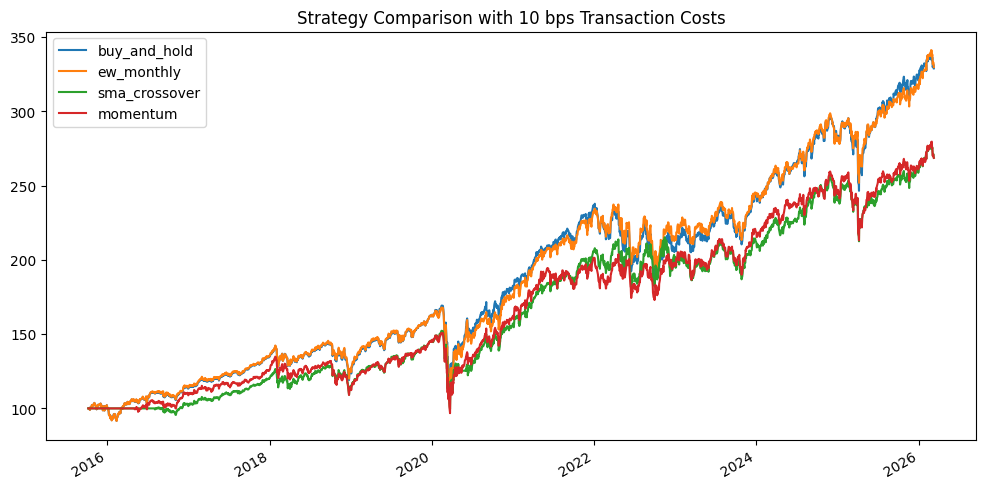

In [27]:
sector_res_tc.plot(figsize=(12, 6), title='Strategy Comparison with 10 bps Transaction Costs');

In [28]:
sector_res_tc.display()

Stat                 buy_and_hold    ew_monthly    sma_crossover    momentum
-------------------  --------------  ------------  ---------------  ----------
Start                2015-10-07      2015-10-07    2015-10-07       2015-10-07
End                  2026-03-11      2026-03-11    2026-03-11       2026-03-11
Risk-free rate       0.00%           0.00%         0.00%            0.00%

Total Return         228.96%         229.86%       168.80%          168.70%
Daily Sharpe         0.76            0.77          0.67             0.65
Daily Sortino        1.17            1.18          1.01             1.00
CAGR                 12.10%          12.13%        9.95%            9.94%
Max Drawdown         -35.71%         -36.88%       -34.67%          -35.83%
Calmar Ratio         0.34            0.33          0.29             0.28

MTD                  -2.85%          -3.35%        -3.39%           -3.82%
3m                   1.70%           4.22%         3.47%            2.18%
6m              

Compare these results to the zero-cost versions above. Transaction costs hurt the more active strategies (momentum, SMA crossover) more than buy-and-hold. This is a fundamental insight: **the more you trade, the more you pay**. Your strategy needs to generate enough alpha to overcome those costs. The buy-and-hold strategy barely notices, since it only trades once.

## In-Sample vs. Out-of-Sample Testing

One of the most important concepts in backtesting is the distinction between **in-sample** and **out-of-sample** data. 

- **In-sample** (training): the data you use to develop and calibrate your strategy. You look at the data, spot patterns, and design your rules.
- **Out-of-sample** (testing): data that you **set aside** and don't look at until your strategy is finalized. This tells you how the strategy would have performed on data it's never seen.

Why does this matter? Because it's easy to design a strategy that works on data you've already seen. That's just curve fitting. The real test is whether your strategy generalizes to new data. 

Let's split our sector data in half and see how our strategies perform in each period. We'll use the first half to "develop" our strategy (in-sample) and the second half to test it (out-of-sample). Note that our simple moving average strategy doesn't have parameters that we optimized on the in-sample data -- we picked 50 and 200 days based on convention, not because we searched for the best values. But even so, it's instructive to see how performance differs across time periods.

In [29]:
# Split data roughly in half
midpoint = sector_data.index[len(sector_data) // 2]
print(f"Split date: {midpoint.strftime('%Y-%m-%d')}")
print(f"In-sample:    {sector_data.index[0].strftime('%Y-%m-%d')} to {midpoint.strftime('%Y-%m-%d')}")
print(f"Out-of-sample: {midpoint.strftime('%Y-%m-%d')} to {sector_data.index[-1].strftime('%Y-%m-%d')}")

data_in = sector_data.loc[:midpoint].copy()
data_out = sector_data.loc[midpoint:].copy()

Split date: 2020-12-21
In-sample:    2015-10-08 to 2020-12-21
Out-of-sample: 2020-12-21 to 2026-03-11


We need to redefine our strategies for each sub-period. The `bt` package requires new strategy objects for each backtest (you can't reuse the same strategy object). Note that for the SMA crossover strategy, the signal is recalculated from the data in each sub-period.

In [30]:
# Recalculate signals for each sub-period
signal_in = data_in.rolling(50).mean() > data_in.rolling(200).mean()
signal_out = data_out.rolling(50).mean() > data_out.rolling(200).mean()

# In-sample strategies
bh_in = bt.Strategy('buy_and_hold', [bt.algos.RunOnce(), bt.algos.SelectAll(), 
                                      bt.algos.WeighEqually(), bt.algos.Rebalance()])
cross_in = bt.Strategy('sma_crossover', [bt.algos.RunMonthly(), bt.algos.SelectWhere(signal_in),
                                          bt.algos.WeighEqually(), bt.algos.Rebalance()])

# Out-of-sample strategies
bh_out = bt.Strategy('buy_and_hold', [bt.algos.RunOnce(), bt.algos.SelectAll(), 
                                       bt.algos.WeighEqually(), bt.algos.Rebalance()])
cross_out = bt.Strategy('sma_crossover', [bt.algos.RunMonthly(), bt.algos.SelectWhere(signal_out),
                                           bt.algos.WeighEqually(), bt.algos.Rebalance()])

# Run backtests
res_in = bt.run(bt.Backtest(bh_in, data_in), bt.Backtest(cross_in, data_in))
res_out = bt.run(bt.Backtest(bh_out, data_out), bt.Backtest(cross_out, data_out))

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:00<00:00,  1.95it/s]

100%|██████████| 2/2 [00:01<00:00,  1.63it/s]

100%|██████████| 2/2 [00:01<00:00,  1.67it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:00<00:00,  1.97it/s]

100%|██████████| 2/2 [00:01<00:00,  1.68it/s]

100%|██████████| 2/2 [00:01<00:00,  1.72it/s]

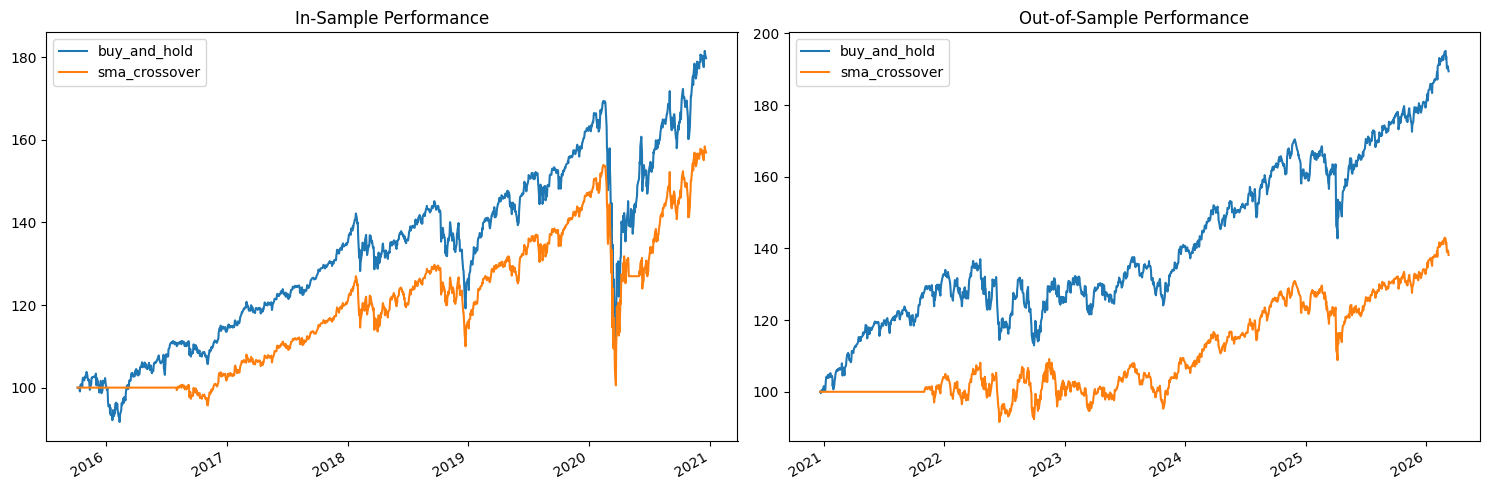

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_in.plot(ax=axes[0])
axes[0].set_title('In-Sample Performance')

res_out.plot(ax=axes[1])
axes[1].set_title('Out-of-Sample Performance')

plt.tight_layout()
plt.show()

In [32]:
print("=== In-Sample Results ===")
res_in.display()

print("\n=== Out-of-Sample Results ===")
res_out.display()

=== In-Sample Results ===
Stat                 buy_and_hold    sma_crossover
-------------------  --------------  ---------------
Start                2015-10-07      2015-10-07
End                  2020-12-21      2020-12-21
Risk-free rate       0.00%           0.00%

Total Return         79.76%          56.92%
Daily Sharpe         0.70            0.59
Daily Sortino        1.04            0.86
CAGR                 11.92%          9.04%
Max Drawdown         -35.71%         -34.67%
Calmar Ratio         0.33            0.26

MTD                  1.41%           0.98%
3m                   12.09%          10.18%
6m                   18.60%          21.65%
YTD                  10.49%          6.72%
1Y                   10.96%          7.14%
3Y (ann.)            10.18%          9.35%
5Y (ann.)            12.60%          9.43%
10Y (ann.)           -               -
Since Incep. (ann.)  11.92%          9.04%

Daily Sharpe         0.70            0.59
Daily Sortino        1.04            0.86
D

Look at the Sharpe ratios and total returns across the two periods. Does the SMA crossover strategy perform consistently? Or does it do well in one period and poorly in another? This kind of analysis is essential before putting real money behind a strategy. If performance is wildly different across periods, your strategy may be capturing noise rather than a real signal.

In practice, more sophisticated approaches use **walk-forward analysis**: you train on a rolling window of data, test on the next period, then roll forward. This gives you a series of out-of-sample results that better reflect how the strategy would have performed in real time.

## Working with BT Results

The `bt` results object contains a lot of useful data beyond the summary statistics. You can access the underlying return series, look at individual strategy stats as DataFrames, and create custom analyses.

### Accessing Returns and Prices

You can pull out the strategy's daily prices and returns as `pandas` objects for your own analysis.

In [33]:
# The .prices attribute gives you the daily portfolio value (indexed to 100)
prices = sector_res.prices
print(type(prices))
prices.tail()

<class 'pandas.DataFrame'>


,buy_and_hold,ew_monthly,sma_crossover,momentum
2026-03-05,334.078617,336.501157,282.621810,286.749441
2026-03-06,330.070465,333.166367,279.821019,284.422764
2026-03-09,331.929281,334.341181,280.807640,285.354072
2026-03-10,330.659168,332.845371,279.551351,283.412781
2026-03-11,329.293650,331.254769,278.215433,283.055996


In [34]:
# Get the stats as a DataFrame for custom analysis
stats_df = sector_res.stats
stats_df.loc[['total_return', 'cagr', 'daily_sharpe', 'max_drawdown', 'daily_vol']]

,buy_and_hold,ew_monthly,sma_crossover,momentum
total_return,2.292936,2.312548,1.782154,1.83056
cagr,0.121101,0.12174,0.103122,0.104948
daily_sharpe,0.758852,0.769049,0.686108,0.684144
max_drawdown,-0.357105,-0.368802,-0.34666,-0.358264
daily_vol,0.170266,0.168335,0.162892,0.166688


### Rolling Sharpe Ratio

A strategy's Sharpe ratio can change dramatically over time. Looking at a **rolling Sharpe ratio** helps you understand whether the strategy's risk-adjusted performance is stable or if it goes through long stretches of underperformance. Let's calculate a 1-year rolling Sharpe for each strategy using the daily returns.

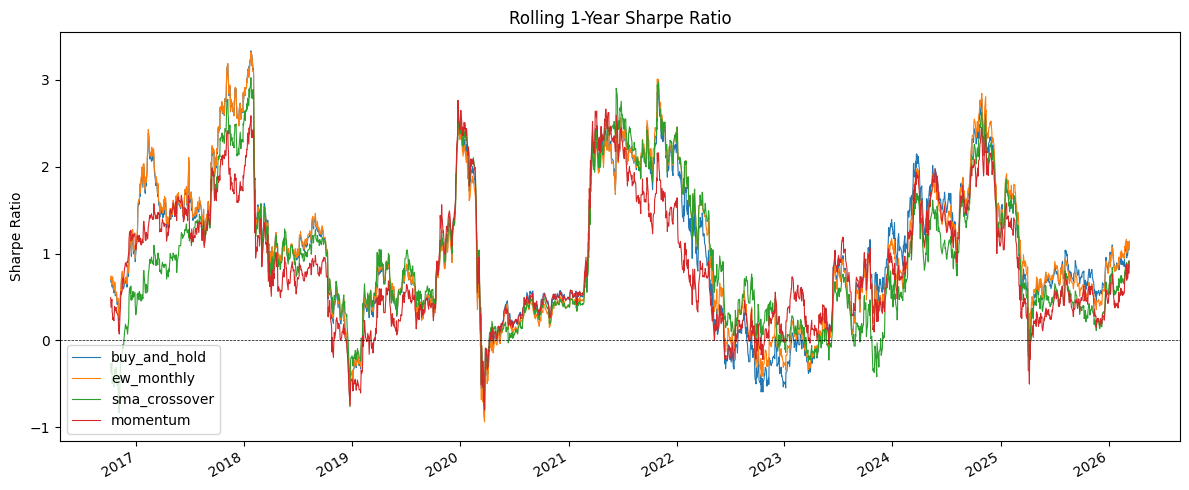

In [35]:
# Calculate daily returns from the strategy prices
daily_returns = sector_res.prices.pct_change().dropna()

# Rolling 1-year (252 trading days) Sharpe ratio
rolling_sharpe = (daily_returns.rolling(252).mean() / daily_returns.rolling(252).std()) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 5))
rolling_sharpe.plot(ax=ax, linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax.set_title('Rolling 1-Year Sharpe Ratio')
ax.set_ylabel('Sharpe Ratio')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

Notice how much the Sharpe ratio bounces around. A strategy with a great overall Sharpe might have long periods where it's negative. This is the reality of trading -- even good strategies go through painful drawdowns. The question is whether you have the discipline (and the capital) to stick with it.

### Return Distributions

Let's look at how the monthly returns are distributed for each strategy. This gives you a sense of the **shape** of returns -- are they symmetric? Do they have fat tails? Strategies with similar average returns can have very different distributions.

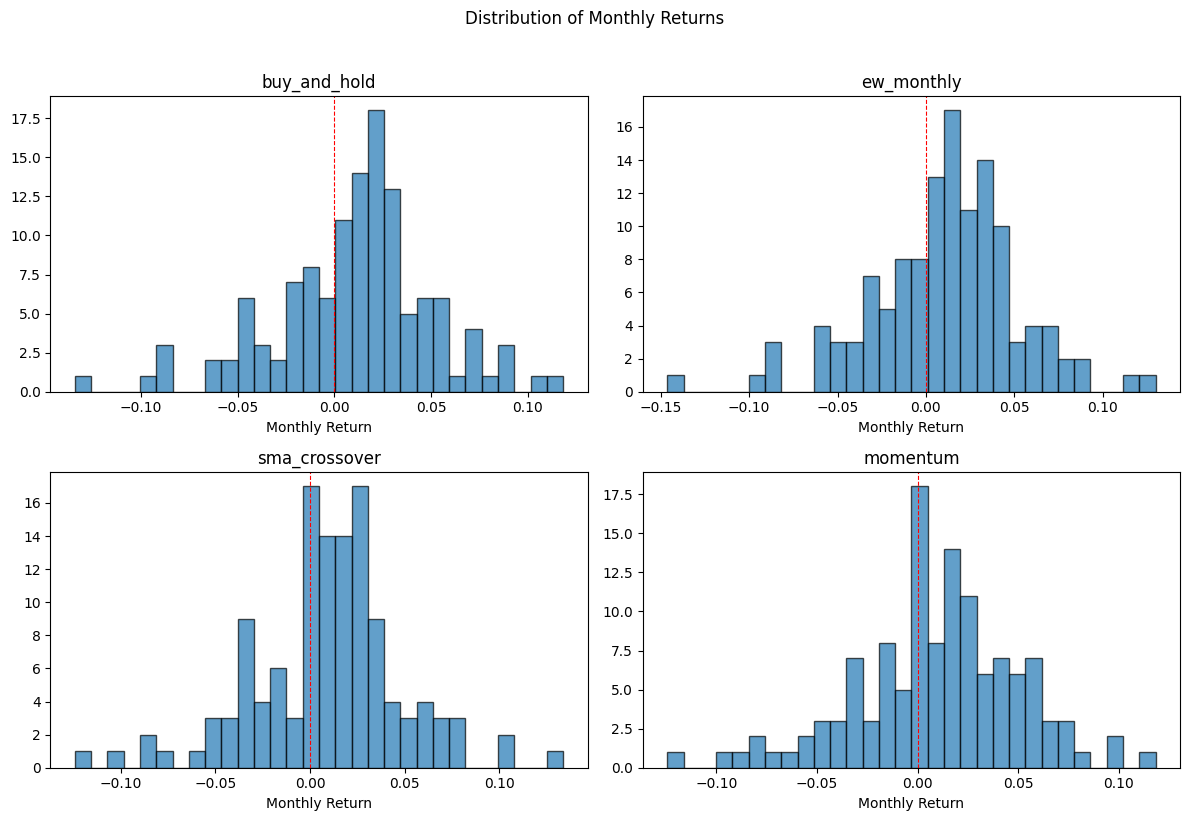

In [36]:
# Monthly returns for each strategy
monthly_returns = sector_res.prices.resample('ME').last().pct_change().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, monthly_returns.columns):
    ax.hist(monthly_returns[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('Monthly Return')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8)

plt.suptitle('Distribution of Monthly Returns', y=1.02)
plt.tight_layout()
plt.show()

## Key Takeaways

Let's summarize what we've learned about backtesting.

1. **Always compare to a benchmark.** It doesn't matter if your strategy makes money in absolute terms. What matters is whether it makes money **relative to doing nothing** (or something simple, like buy-and-hold). If your complex strategy can't beat equal weight, it's not worth the complexity.

2. **Transaction costs matter.** A strategy that looks great with zero costs may look mediocre or bad once you account for real-world trading frictions. Always include realistic cost assumptions.

3. **Test out-of-sample.** In-sample performance tells you how well your strategy fits the past. Out-of-sample performance tells you whether it might work in the future. The gap between the two is a measure of how much you've overfit.

4. **Simpler is usually better.** Strategies with fewer parameters are harder to overfit and more likely to work going forward. A 50/200-day moving average crossover has essentially zero free parameters (those numbers are industry convention, not optimized).

5. **Look beyond total return.** Sharpe ratio, maximum drawdown, turnover, and how performance varies over time all matter. A strategy that returns 15% per year with a 50% max drawdown is very different from one that returns 10% with a 15% max drawdown.

6. **Be skeptical.** Most backtested strategies don't work in real life. Survivorship bias, look-ahead bias, transaction costs, and regime changes all conspire against you. If a strategy seems too good to be true, it probably is.

## Other Tools

The `bt` package is just one of many backtesting frameworks out there. I chose it because the **declarative, algo-tree approach** lets you focus on *what* a strategy does rather than wiring up an event loop. That makes it a good fit for learning. But it's worth knowing what else is available.

### Zipline

[Zipline](https://zipline.ml4trading.io) was originally built by [Quantopian](https://www.bloomberg.com/news/articles/2020-12-16/quant-trading-platform-quantopian-closes-down), a now-defunct platform that let retail investors build and test trading strategies. It is now maintained as `zipline-reloaded`. Zipline uses an **event-driven** architecture — your code processes data bar-by-bar, giving you much more granular control over order types, slippage models, and execution logic. The trade-off is a steeper learning curve and heavier dependencies. Related tools from the same ecosystem include [alphalens](https://alphalens.ml4trading.io) for analyzing sources of risk and return, and [pyfolio](https://pyfolio.ml4trading.io) for creating performance tear sheets.

### Backtrader

[Backtrader](https://www.backtrader.com) is another event-driven framework, similar in philosophy to Zipline. It is more flexible than `bt` for complex order logic and supports **live trading** connections to brokers like Interactive Brokers. It has good documentation and an active community, but the API is more complex.

### Backtesting.py

There is also a package simply called [Backtesting](https://pypi.org/project/Backtesting/). It is lightweight and easy to get started with, though less feature-rich than the others.

### How Do They Compare?

| Feature | bt | Zipline | Backtrader |
| :--- | :--- | :--- | :--- |
| **Approach** | Declarative (algo trees) | Event-driven | Event-driven |
| **Best for** | Asset allocation, strategy comparison | Granular trade simulation | Complex strategies, live trading |
| **Learning curve** | Low | High | Medium |
| **Live trading** | No | No | Yes (Interactive Brokers) |
| **Trade-level control** | Limited | Extensive | Extensive |

For this course, `bt` is the right choice — the simple API lets us focus on the *ideas* behind backtesting rather than implementation details. If you move into more serious quantitative work, Zipline or Backtrader give you the control you would need.

Trading firms and hedge funds will have developed most of this in-house. For example, [Goldman Sachs has their own tools](https://developer.gs.com/docs/gsquant/).